In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

In [3]:
# merge customer and loyalty member datasets, drop duplicate name column, convert age and points_earned to nullable integers, save to new csv
customer = pd.read_csv('dataset/customers.csv')
loyal_customer = pd.read_csv('dataset/loyalty_members.csv')
key = 'email'
allCustomers = pd.merge(customer, loyal_customer, on=key, how='outer', indicator=False)
allCustomers.drop(columns='name_y', inplace=True)
allCustomers.rename(columns={'name_x': 'name'}, inplace=True)
allCustomers['age'] = allCustomers['age'].astype(pd.Int64Dtype())
allCustomers['points_earned'] = allCustomers['points_earned'].astype(pd.Int64Dtype())
allCustomers.to_csv('dataset/all_customers.csv', index=False)
allCustomers.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   name              500 non-null    object
 1   email             500 non-null    object
 2   phone             500 non-null    object
 3   loyalty_enrolled  500 non-null    object
 4   loyalty_id        308 non-null    object
 5   tier              308 non-null    object
 6   points_earned     308 non-null    Int64 
 7   gender            308 non-null    object
 8   age               308 non-null    Int64 
 9   birthday          308 non-null    object
 10  occupation        308 non-null    object
dtypes: Int64(2), object(9)
memory usage: 44.1+ KB


In [4]:
orders = pd.read_csv('dataset/orders.csv')
allCustomerOrders = pd.merge(orders, allCustomers, on=key, how='outer', indicator=False)
allCustomerOrders.to_csv('dataset/all_customers_orders.csv', index=False)

In [5]:
memberOrders = allCustomerOrders[allCustomerOrders['loyalty_enrolled'] == 'Y'].copy()
memberOrders.head(10)

,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,name,phone,loyalty_enrolled,loyalty_id,tier,points_earned,gender,age,birthday,occupation
0,T000957,abigail.chen229@hotmail.com,2025-01-13,30,101.93,Abigail Chen,1-647-44-4022,Y,L000230,Frequent,4022,Male,29,1996-03-07,Nurse
1,T001882,abigail.chen229@hotmail.com,2025-04-13,100,94.43,Abigail Chen,1-647-44-4022,Y,L000230,Frequent,4022,Male,29,1996-03-07,Nurse
2,T003716,abigail.chen229@hotmail.com,2025-08-26,104,8.49,Abigail Chen,1-647-44-4022,Y,L000230,Frequent,4022,Male,29,1996-03-07,Nurse
3,T004058,abigail.chen229@hotmail.com,2025-09-21,77,141.43,Abigail Chen,1-647-44-4022,Y,L000230,Frequent,4022,Male,29,1996-03-07,Nurse
4,T004237,abigail.chen229@hotmail.com,2025-10-05,82,55.94,Abigail Chen,1-647-44-4022,Y,L000230,Frequent,4022,Male,29,1996-03-07,Nurse
5,T000710,abigail.chow473@gmail.com,2024-12-22,148,65.74,Abigail Chow,1-437-515-2073,Y,L000474,Frequent,4733,Male,39,1986-03-16,Consultant
6,T001261,abigail.chow473@gmail.com,2025-02-15,146,54.96,Abigail Chow,1-437-515-2073,Y,L000474,Frequent,4733,Male,39,1986-03-16,Consultant
7,T001342,abigail.chow473@gmail.com,2025-02-24,149,150.77,Abigail Chow,1-437-515-2073,Y,L000474,Frequent,4733,Male,39,1986-03-16,Consultant
8,T001455,abigail.chow473@gmail.com,2025-03-07,151,59.44,Abigail Chow,1-437-515-2073,Y,L000474,Frequent,4733,Male,39,1986-03-16,Consultant
9,T001847,abigail.chow473@gmail.com,2025-04-09,146,24.98,Abigail Chow,1-437-515-2073,Y,L000474,Frequent,4733,Male,39,1986-03-16,Consultant


In [6]:
nonmemberOrders = allCustomerOrders[allCustomerOrders['loyalty_enrolled'] == 'N'].copy()
nonmemberOrders.drop(columns=['loyalty_id', 'tier', 'points_earned', 'gender', 'age', 'birthday', 'occupation'], inplace=True)
nonmemberOrders.head(10)

,transaction_id,email,transaction_date,time_spent_min,total_bill_amount,name,phone,loyalty_enrolled
67,T000586,abigail.thompson339@gmail.com,2024-12-13,68,102.92,Abigail Thompson,1-905-530-945,N
68,T000702,abigail.thompson339@gmail.com,2024-12-21,90,100.23,Abigail Thompson,1-905-530-945,N
69,T000804,abigail.thompson339@gmail.com,2024-12-28,97,26.47,Abigail Thompson,1-905-530-945,N
70,T002714,abigail.thompson339@gmail.com,2025-06-18,95,125.92,Abigail Thompson,1-905-530-945,N
71,T002934,abigail.thompson339@gmail.com,2025-07-03,56,70.43,Abigail Thompson,1-905-530-945,N
72,T003331,abigail.thompson339@gmail.com,2025-07-31,97,191.44,Abigail Thompson,1-905-530-945,N
99,T000981,aiden.gonzalez136@yahoo.com,2025-01-15,80,118.73,Aiden Gonzalez,1-905-677-2297,N
100,T001135,aiden.gonzalez136@yahoo.com,2025-02-01,113,19.98,Aiden Gonzalez,1-905-677-2297,N
101,T001720,aiden.gonzalez136@yahoo.com,2025-03-30,76,24.98,Aiden Gonzalez,1-905-677-2297,N
102,T002635,aiden.gonzalez136@yahoo.com,2025-06-14,142,142.91,Aiden Gonzalez,1-905-677-2297,N


<font size="5">
Investigate frequency of visits of members and non-members
</font>

In [7]:
nonmemberBehaviour = nonmemberOrders.groupby('email').agg(
    # --- Stats for 'total bill amount' ---
    median_spend  = ('total_bill_amount', 'median'),
    total_spend = ('total_bill_amount', 'sum'),
    total_visit = ('total_bill_amount', 'count'),
    
    # --- Stats for 'time spent' ---
    median_time  = ('time_spent_min', 'median'),
    total_time = ('time_spent_min', 'sum'),
)
number_of_non_members = nonmemberOrders['email'].nunique()
nonmemberBehaviour['normalized_total_visit'] = nonmemberBehaviour['total_visit'] / number_of_non_members
nonmemberBehaviour.describe()

,median_spend,total_spend,total_visit,median_time,total_time,normalized_total_visit
count,192.000000,192.000000,192.000000,192.000000,192.000000,192.000000
mean,74.806198,752.922500,8.901042,101.536458,903.031250,0.046360
std,20.575408,288.709468,2.869883,14.677644,306.081225,0.014947
min,28.980000,161.190000,3.000000,65.000000,271.000000,0.015625
25%,58.432500,564.422500,7.000000,92.000000,680.250000,0.036458
50%,74.140000,729.470000,9.000000,102.000000,882.500000,0.046875
75%,89.688750,912.862500,11.000000,110.250000,1099.250000,0.057292
max,131.315000,1895.350000,19.000000,147.000000,2042.000000,0.098958


In [8]:
memberBehaviour = memberOrders.groupby('email').agg(
    # --- Stats for 'total bill amount' ---
    median_spend  = ('total_bill_amount', 'median'),
    total_spend = ('total_bill_amount', 'sum'),
    total_visit = ('total_bill_amount', 'count'),
    
    # --- Stats for 'time spent' ---
    median_time  = ('time_spent_min', 'median'),
    total_time = ('time_spent_min', 'sum'),
)
number_of_members = memberOrders['email'].nunique()
memberBehaviour['normalized_total_visit'] = memberBehaviour['total_visit'] / number_of_members
memberBehaviour.describe()

,median_spend,total_spend,total_visit,median_time,total_time,normalized_total_visit
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,77.881672,772.209838,9.061688,100.547078,913.850649,0.029421
std,23.944368,288.469521,2.907828,15.178586,313.760542,0.009441
min,27.480000,139.140000,2.000000,56.000000,190.000000,0.006494
25%,59.450000,548.695000,7.000000,90.500000,689.750000,0.022727
50%,75.965000,738.800000,9.000000,100.750000,900.500000,0.029221
75%,91.240000,967.955000,11.000000,111.000000,1121.000000,0.035714
max,168.065000,1550.550000,19.000000,146.000000,1996.000000,0.061688


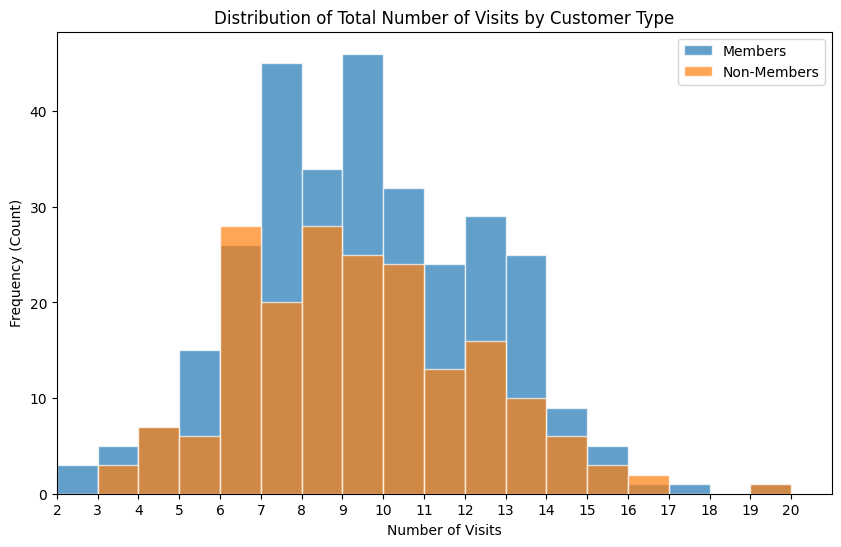

In [9]:
#plotting histograms to compare total visits between members and non-members

my_bins = np.arange(2, 21) 

plt.figure(figsize=(10, 6))

plt.hist(memberBehaviour['total_visit'], 
         bins=my_bins,      
         alpha=0.7, 
         label='Members',
         edgecolor='white') 

plt.hist(nonmemberBehaviour['total_visit'], 
         bins=my_bins,     
         alpha=0.7, 
         label='Non-Members',
         edgecolor='white')

plt.title('Distribution of Total Number of Visits by Customer Type')
plt.xlabel('Number of Visits')
plt.ylabel('Frequency (Count)')


plt.xticks(my_bins)
plt.xlim(2, 21)

plt.legend()  
plt.show()

Because there are more members than non-members, it is reasonable that members contribute more visits. However, it is important to note that more non-members visited 4 times, 6 times, 16times and 19 times than members.

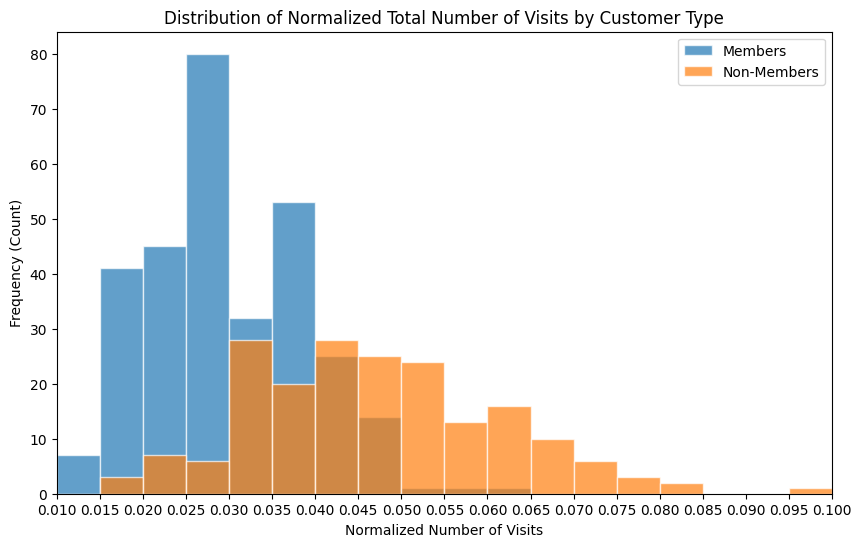

In [10]:
#plotting histograms to compare normalized total visits between members and non-members

normalized_bins = np.linspace(0.01, 0.1, 19) # number of visits range from 2 to 19, so we create 19 points using linspace

plt.figure(figsize=(10, 6))

plt.hist(memberBehaviour['normalized_total_visit'], 
         bins=normalized_bins,      
         alpha=0.7, 
         label='Members',
         edgecolor='white') 

plt.hist(nonmemberBehaviour['normalized_total_visit'], 
         bins=normalized_bins,      
         alpha=0.7, 
         label='Non-Members',
         edgecolor='white')

plt.title('Distribution of Normalized Total Number of Visits by Customer Type')
plt.xlabel('Normalized Number of Visits')
plt.ylabel('Frequency (Count)')


plt.xticks(normalized_bins)
plt.xlim(0.01, 0.1)

plt.legend()  
plt.show()

In [55]:
t_statistic, p_value = stats.ttest_ind(memberBehaviour['normalized_total_visit'], nonmemberBehaviour['normalized_total_visit'], equal_var=False)
print("--- T-Test Results ---")
print(f"T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nConclusion: The difference is STATISTICALLY SIGNIFICANT.")
else:
    print("\nConclusion: The difference is NOT statistically significant.")

--- T-Test Results ---
T-statistic: -14.0519
P-value: 0.0000

Conclusion: The difference is STATISTICALLY SIGNIFICANT.


From the normalized histogram, we can see non-members visit the business more frequently than members.

<font size="5">
Investigate dollar spent of members and non-members
</font>

/var/folders/1j/0pk0gx_s09g3m4s9nlsc37_r0000gn/T/ipykernel_31137/3287706062.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot,


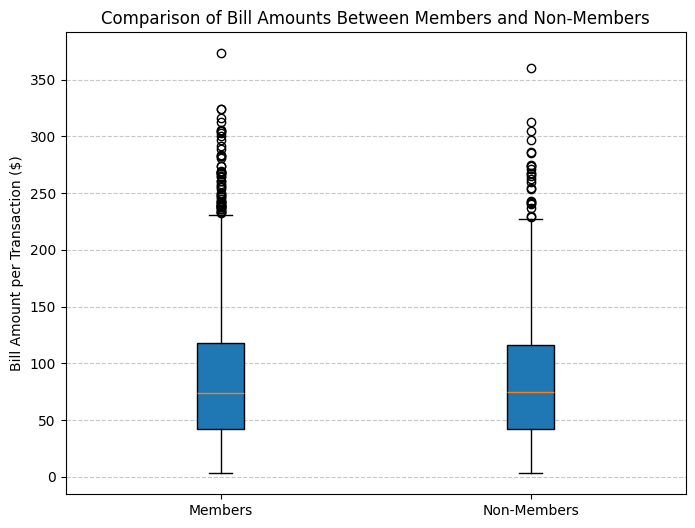

In [56]:
data_to_plot = [
    memberOrders['total_bill_amount'], 
    nonmemberOrders['total_bill_amount']
]

plt.figure(figsize=(8, 6))


plt.boxplot(data_to_plot, 
            patch_artist=True, 
            labels=['Members', 'Non-Members'])

plt.title('Comparison of Bill Amounts Between Members and Non-Members')
plt.ylabel('Bill Amount per Transaction ($)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.show()

In [57]:
memberOrders['total_bill_amount'].describe()

count    2791.000000
mean       85.216994
std        56.889171
min         2.990000
25%        42.000000
50%        73.970000
75%       117.935000
max       373.240000
Name: total_bill_amount, dtype: float64

In [58]:
nonmemberOrders['total_bill_amount'].describe()

count    1709.000000
mean       84.588133
std        55.732281
min         2.990000
25%        41.940000
50%        74.460000
75%       116.430000
max       360.320000
Name: total_bill_amount, dtype: float64

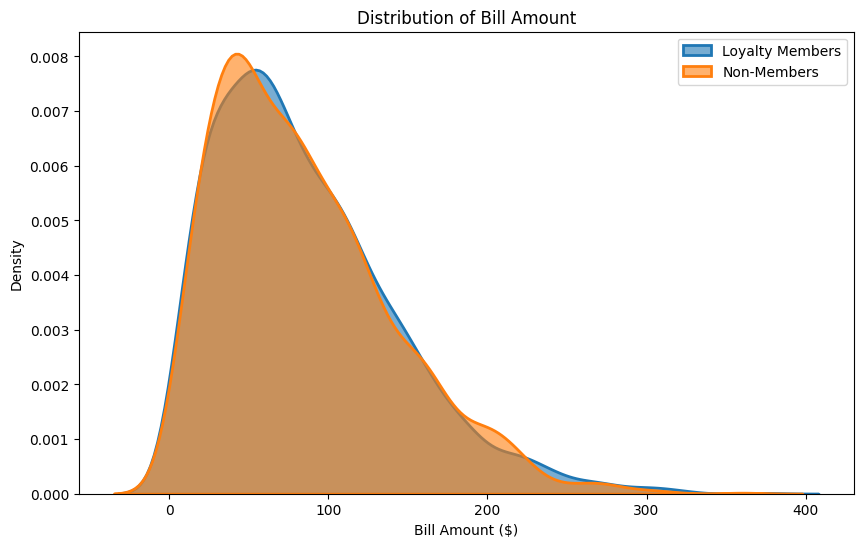

In [59]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=memberOrders['total_bill_amount'], 
    label='Loyalty Members', 
    fill=True,    # Fill the area under the curve
    alpha=0.6,
    linewidth=2
)


sns.kdeplot(
    data=nonmemberOrders['total_bill_amount'], 
    label='Non-Members', 
    fill=True,
    alpha=0.6,
    linewidth=2
)

plt.title('Distribution of Bill Amount')
plt.xlabel('Bill Amount ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

From the box and density plot, we can see there is no significant difference between the spending pattern  between members and non-members

<font size="5">
Investigate relationship between dollar spent and time spent across members and non-members
</font>

In [60]:
# compare dollar spent per minute in restaturant across members and non-members
memberOrders['dollar_per_min'] = memberOrders['total_bill_amount'] / memberOrders['time_spent_min']
nonmemberOrders['dollar_per_min'] = nonmemberOrders['total_bill_amount'] / nonmemberOrders['time_spent_min']

/var/folders/1j/0pk0gx_s09g3m4s9nlsc37_r0000gn/T/ipykernel_31137/3670333445.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot2,


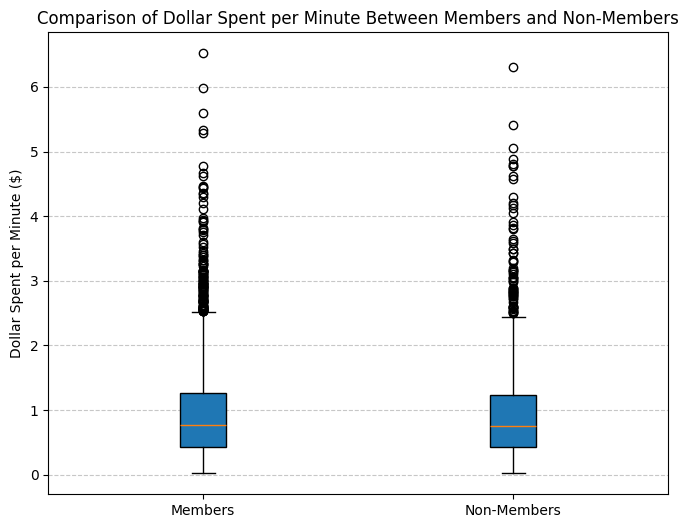

In [61]:
data_to_plot2 = [
    memberOrders['dollar_per_min'], 
    nonmemberOrders['dollar_per_min']
]

plt.figure(figsize=(8, 6))


plt.boxplot(data_to_plot2, 
            patch_artist=True, 
            labels=['Members', 'Non-Members'])

plt.title('Comparison of Dollar Spent per Minute Between Members and Non-Members')
plt.ylabel('Dollar Spent per Minute ($)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7) # Add a horizontal grid
plt.show()

In [62]:
memberOrders['dollar_per_min'].describe()

count    2791.000000
mean        0.950813
std         0.747637
min         0.020067
25%         0.426620
50%         0.765323
75%         1.263202
max         6.520476
Name: dollar_per_min, dtype: float64

In [63]:
nonmemberOrders['dollar_per_min'].describe()

count    1709.000000
mean        0.934009
std         0.741334
min         0.024191
25%         0.421217
50%         0.757955
75%         1.230566
max         6.306571
Name: dollar_per_min, dtype: float64

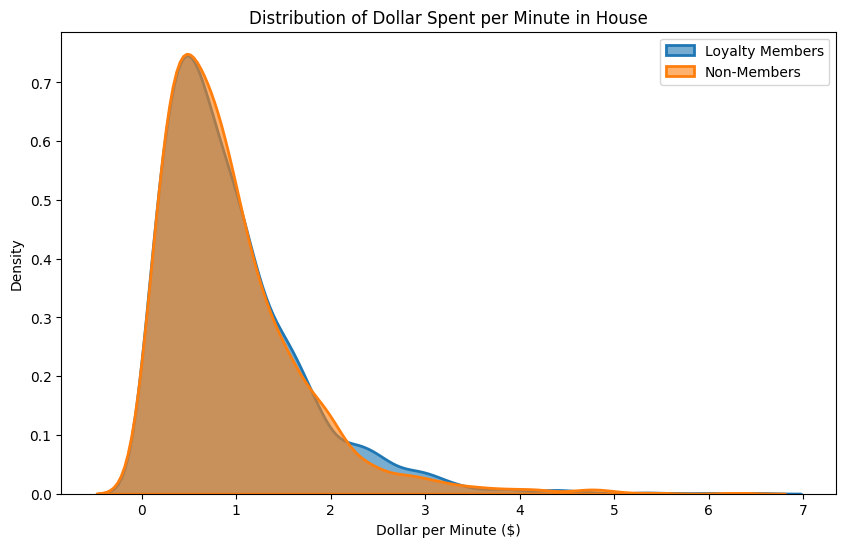

In [64]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=memberOrders['dollar_per_min'], 
    label='Loyalty Members', 
    fill=True,    # Fill the area under the curve
    alpha=0.6,
    linewidth=2
)


sns.kdeplot(
    data=nonmemberOrders['dollar_per_min'], 
    label='Non-Members', 
    fill=True,
    alpha=0.6,
    linewidth=2
)

plt.title('Distribution of Dollar Spent per Minute in House')
plt.xlabel('Dollar per Minute ($)')
plt.ylabel('Density')
plt.legend()
plt.show()

From the box and the density plot, we can see there is no significant difference between the spending pattern per minute in store between members and non-members

<font size="5">
Investigate difference between item type ordered by member and non-member
</font>

In [18]:
order_details = pd.read_csv('dataset/order_details.csv')
order_details.head()

,transaction_id,email,item_type,item_id,item_name,category,unit_price_cad,quantity,line_amount_cad
0,T000001,mason.chan230@icloud.com,food,F004,Mac & Cheese,Mains,14.49,1,14.49
1,T000001,mason.chan230@icloud.com,food,F002,Chicken Wings,Appetizers,15.49,1,15.49
2,T000001,mason.chan230@icloud.com,food,F002,Chicken Wings,Appetizers,15.49,1,15.49
3,T000001,mason.chan230@icloud.com,drink,D009,Energy Drink,Non-alcoholic,4.99,1,4.99
4,T000001,mason.chan230@icloud.com,drink,D009,Energy Drink,Non-alcoholic,4.99,1,4.99


In [19]:
loyalty_identifier = allCustomers[['email','loyalty_enrolled']]
order_details_loyaltyID = pd.merge(order_details, loyalty_identifier, on=key, how='left', indicator=False)
order_details_loyaltyID.head()

,transaction_id,email,item_type,item_id,item_name,category,unit_price_cad,quantity,line_amount_cad,loyalty_enrolled
0,T000001,mason.chan230@icloud.com,food,F004,Mac & Cheese,Mains,14.49,1,14.49,Y
1,T000001,mason.chan230@icloud.com,food,F002,Chicken Wings,Appetizers,15.49,1,15.49,Y
2,T000001,mason.chan230@icloud.com,food,F002,Chicken Wings,Appetizers,15.49,1,15.49,Y
3,T000001,mason.chan230@icloud.com,drink,D009,Energy Drink,Non-alcoholic,4.99,1,4.99,Y
4,T000001,mason.chan230@icloud.com,drink,D009,Energy Drink,Non-alcoholic,4.99,1,4.99,Y


--- Percentages Table ---
item_type            drink  entertainment      food
loyalty_enrolled                                   
N                 0.459309       0.254206  0.286485
Y                 0.460777       0.257870  0.281353


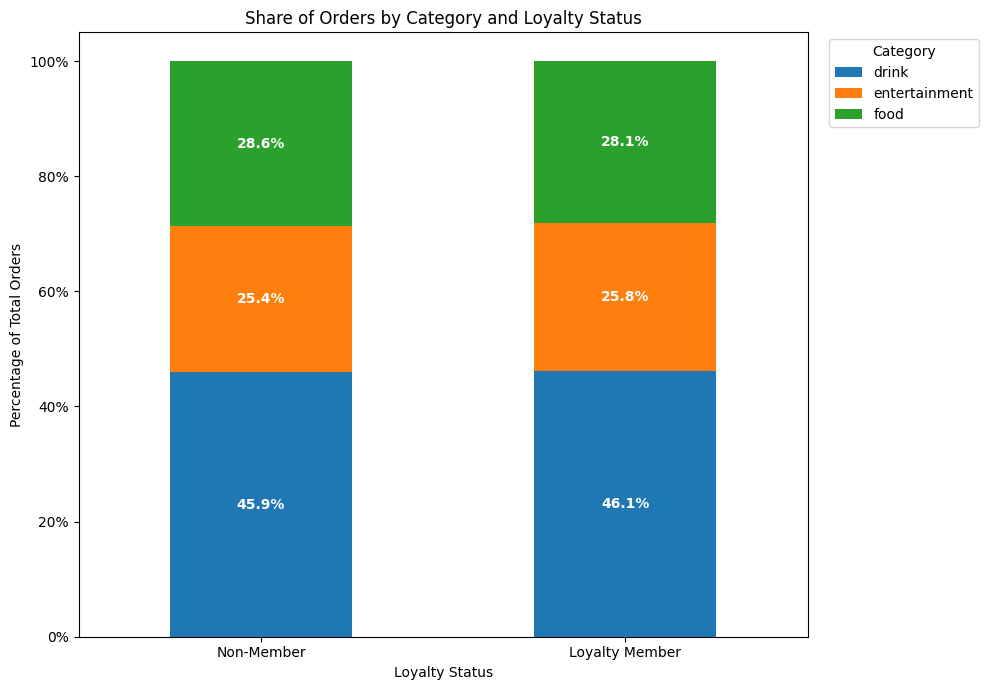

In [23]:
# --- 3. Get the counts (Numerator) ---
# This counts every combination of loyalty status and category
# (e.g., Member-food, Member-drink, etc.)
counts_df = order_details_loyaltyID.groupby(['loyalty_enrolled', 'item_type']).size()

# --- 4. Get the total counts per loyalty status (Denominator) ---
# This gets the total orders for 'Member' and 'Non-Member'
total_counts = order_details_loyaltyID.groupby('loyalty_enrolled').size()

# --- 5. Calculate the Percentages ---
# We divide the category counts by the total counts for that group
# .unstack() pivots the 'category' into columns, which is needed for plotting
pct_df = (counts_df / total_counts).unstack()

print("--- Percentages Table ---")
print(pct_df)

# --- 6. Plot the 100% Stacked Bar Chart ---
ax = pct_df.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 7),
    title='Share of Orders by Category and Loyalty Status'
)

# --- 7. Format the Plot ---
ax.set_xlabel('Loyalty Status')
ax.set_ylabel('Percentage of Total Orders')
new_labels = ['Non-Member', 'Loyalty Member'] 
ax.set_xticklabels(new_labels, rotation=0)
plt.xticks(rotation=0) # Keep x-axis labels horizontal
ax.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Format the y-axis to show as percentages
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Add labels to the segments (optional but very helpful)
for container in ax.containers:
    # Format the label to be a percentage
    labels = [f'{v.get_height():.1%}' if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', weight='bold')

plt.tight_layout() # Adjust plot to prevent labels from being cut off